# ResNet18 ImageNet Probabilities → Random Forest Cloud Classifier

Option C transfer learning: pass images through fully pretrained ResNet18 to extract 1000-dim ImageNet softmax vectors, then train a Random Forest on those vectors to classify cloud vs clear_sky. ResNet weights are never modified.

In [1]:
from pathlib import Path
import os
import numpy as np
import cv2
from tqdm.auto import tqdm

IMAGES_PATH = Path("../resources/cloud-images/cloud-classifier-1")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images, cloud_labels
    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        cloud_labels.append(cloud_dir.name)
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            labeled_images[img_path.name] = {"label": cloud_dir.name, "path": str(img_path)}
    return labeled_images, cloud_labels

def load_rgb_images(labeled_images, size=(224, 224)):
    images, labels = [], []
    for image_name in tqdm(labeled_images, total=len(labeled_images)):
        path = labeled_images[image_name]['path']
        if not os.path.exists(path):
            continue
        image = cv2.imread(path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, size)
        images.append(image)
        labels.append(labeled_images[image_name]['label'])
    return np.array(images), np.array(labels)

labeled_images, cloud_labels = index_labeled_images()
images, labels = load_rgb_images(labeled_images)
print(f"Loaded {len(images)} images — shape: {images.shape}, classes: {cloud_labels}")

/Users/lucasnseyep/code/LucasNseyep/belle-weder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 698/698 [00:00<00:00, 1022.84it/s]

Loaded 698 images — shape: (698, 224, 224, 3), classes: ['clear_sky', 'cloud']


In [2]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder

ordinal_encoder = LabelEncoder()
labels_encoded = ordinal_encoder.fit_transform(labels)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(images, labels_encoded))

X_train_imgs, X_test_imgs = images[train_idx], images[test_idx]
y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

print("train:", X_train_imgs.shape, y_train.shape)
print("test: ", X_test_imgs.shape, y_test.shape)

train: (558, 224, 224, 3) (558,)
test:  (140, 224, 224, 3) (140,)


In [3]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet18_Weights
from torch.nn.functional import softmax

weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)
model.eval()

imagenet_classes = weights.meta["categories"]

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_softmax_vectors(image_array, batch_size=32):
    """Run images through ResNet18 and return full 1000-dim softmax vectors."""
    all_probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(image_array), batch_size)):
            batch = image_array[start:start + batch_size]
            tensors = torch.stack([preprocess(img) for img in batch])
            probs = softmax(model(tensors), dim=1).numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs, axis=0).astype(np.float32)

print("Extracting train softmax vectors...")
X_train_probs = extract_softmax_vectors(X_train_imgs)
print("Extracting test softmax vectors...")
X_test_probs = extract_softmax_vectors(X_test_imgs)

print(f"\nX_train_probs: {X_train_probs.shape}")
print(f"X_test_probs:  {X_test_probs.shape}")

Extracting train softmax vectors...


100%|██████████| 18/18 [00:09<00:00,  1.86it/s]


Extracting test softmax vectors...


100%|██████████| 5/5 [00:02<00:00,  2.18it/s]


X_train_probs: (558, 1000)
X_test_probs:  (140, 1000)


## Random Forest on ResNet18 Softmax Features

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_probs, y_train)
y_pred = rf.predict(X_test_probs)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro:  {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=ordinal_encoder.classes_))

Accuracy:  0.9714
F1 macro:  0.9714

              precision    recall  f1-score   support

   clear_sky       0.97      0.97      0.97        70
       cloud       0.97      0.97      0.97        70

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140



## Feature Importance: Which ImageNet Classes Drive the Prediction?

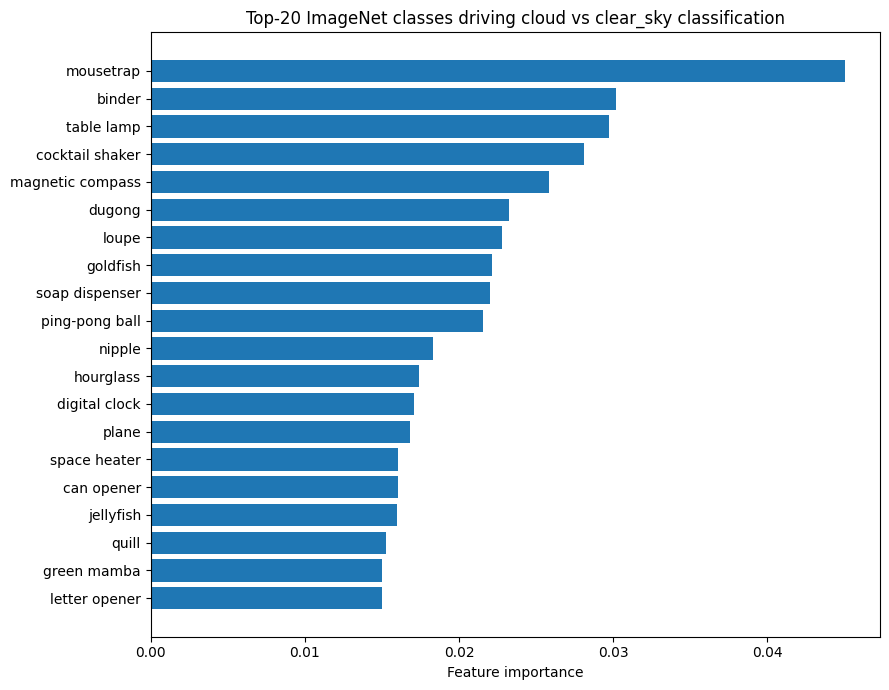

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=imagenet_classes)
top20 = importances.sort_values(ascending=False).head(20).sort_values()

plt.figure(figsize=(9, 7))
plt.barh(top20.index, top20.values)
plt.xlabel("Feature importance")
plt.title("Top-20 ImageNet classes driving cloud vs clear_sky classification")
plt.tight_layout()
plt.show()